# Notebook 06 — Parte III: Clustering de restaurantes

## Qué punto del enunciado cubre
**PARTE III — Clustering (4 pts).** Implementamos **K-Means++**, **DBSCAN** y **BFR** a mano sobre numpy. Elegimos \(k\) con codo + silueta, calibramos `eps/minPts` con *k-distance plot*, comparamos métodos y caracterizamos los segmentos encontrados.

## Fundamento teórico
Deck **«08 - Clustering»**:
- Normalización y métricas de distancia: **pág. 11**.
- K-Means, convergencia y codo: **págs. 19–23**.
- K-Means++ y selección proporcional a \(D(x)^2\): **págs. 24–27**.
- BFR, conjuntos DS/CS/RS, estadísticas \(N/SUM/SUMSQ\) y distancia de Mahalanobis: **págs. 31–42**.
- CURE/DBSCAN para formas arbitrarias: **pág. 45**.
- Métricas intrínsecas/extrínsecas, silueta, SSE, purity y NMI: **págs. 46–49**.

## Decisiones de diseño
1. Los algoritmos consumen exclusivamente `data/gold/features_negocio.parquet`.
2. `review_count` y `poblacion` entran con `log1p`; todas las variables se estandarizan.
3. `metro`, latitud y longitud **no entran al clustering**: evitamos segmentos geográficos por construcción. `metro` queda como etiqueta proxy externa para purity/NMI.
4. DBSCAN corre sobre una muestra reproducible de 6,000 restaurantes porque su implementación exacta requiere \(O(n^2)\) distancias.
5. Ninguna decisión de parámetro se fija a ciegas: una celda diagnostica y la siguiente adopta el valor.

In [1]:
%load_ext autoreload
%autoreload 2
import sys, time
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src import clustering, viz
from src.config import GOLD, SEED

viz.aplicar_estilo()
print("GOLD =", GOLD)
print("Semilla =", SEED)

GOLD = <REPO>/data/gold
Semilla = 42


## Paso 1 — Preparar la matriz de features

La tabla gold mezcla variables numéricas, booleanas y categóricas. Conservamos la ausencia como señal mediante indicadores `_missing`, hacemos *one-hot encoding* de `alcohol` y `wifi`, imputamos medianas en numéricas y estandarizamos. `metro` se reserva para validación externa.

In [2]:
df = clustering.cargar_features()
fm = clustering.preparar_matriz_features(df, incluir_geo=False, incluir_mercado=False)
X = fm.X

print(f"Restaurantes: {len(df):,}")
print(f"Features finales: {X.shape[1]}")
print("Nulos después de preparar:", int(np.isnan(X).sum()))
print("Media absoluta máxima:", round(float(np.abs(X.mean(axis=0)).max()), 8))
print("Desvío estándar mínimo/máximo:",
      round(float(X.std(axis=0).min()), 4), "/", round(float(X.std(axis=0).max()), 4))
print("¿Entró metro?", any(c.startswith("metro_") for c in fm.feature_names))
print("\nPrimeras 18 features:")
print(fm.feature_names[:18])

Restaurantes: 29,314
Features finales: 42
Nulos después de preparar: 0
Media absoluta máxima: 0.0
Desvío estándar mínimo/máximo: 1.0 / 1.0
¿Entró metro? False

Primeras 18 features:
['stars', 'log_review_count', 'is_open', 'n_categorias', 'price_range', 'mediana_ingreso', 'log_poblacion', 'pct_universitarios', 'renta_mediana', 'RestaurantsTakeOut', 'RestaurantsTakeOut_missing', 'BusinessAcceptsCreditCards', 'BusinessAcceptsCreditCards_missing', 'RestaurantsDelivery', 'RestaurantsDelivery_missing', 'RestaurantsReservations', 'RestaurantsReservations_missing', 'OutdoorSeating']


La matriz quedó completa y en una escala común. Que `metro` no aparezca es deliberado: si luego un cluster coincide con una ciudad, será un hallazgo emergente y no una respuesta introducida por nosotros.

## Paso 2 — Validaciones pequeñas antes de usar datos reales

Como en la Parte II, primero comprobamos las piezas matemáticas contra ejemplos controlados: K-Means debe separar dos grupos 1D; DBSCAN debe reconocer dos nubes y dejar un punto remoto como ruido; BFR debe recuperar correctamente \(N\), `SUM`, `SUMSQ`, centroide y varianza.

In [3]:
# K-Means++: ejemplo 1D del deck (págs. 26–27)
toy = np.array([[1.], [2.], [3.], [10.], [11.], [12.]])
toy_km = clustering.kmeans(toy, k=2, seed=SEED)
print("K-Means++ centroides esperados ≈ [2, 11]:",
      np.sort(toy_km["centroids"].ravel()).round(3).tolist())
print("SSE:", round(toy_km["sse"], 3))

# DBSCAN: dos grupos compactos + un outlier
toy_db = np.array([[0,0],[0.1,0],[0,0.1],[5,5],[5.1,5],[5,5.1],[12,12]], float)
toy_db_res = clustering.dbscan(toy_db, eps=0.25, min_pts=3)
print("DBSCAN labels (dos clusters y ruido=-1):", toy_db_res["labels"].tolist())

# BFR: validación de estadísticas suficientes
s = clustering.Summary.from_points(np.array([[1.], [2.], [3.]]))
print("BFR summary N/SUM/SUMSQ/centroide/varianza:",
      s.n, s.sum.tolist(), s.sumsq.tolist(),
      s.centroid.round(3).tolist(), s.var.round(3).tolist())

K-Means++ centroides esperados ≈ [2, 11]: [2.0, 11.0]
SSE: 4.0
DBSCAN labels (dos clusters y ruido=-1): [0, 0, 0, 1, 1, 1, -1]
BFR summary N/SUM/SUMSQ/centroide/varianza: 3 [6.0] [14.0] [2.0] [0.667]


Las tres pruebas reproducen el comportamiento esperado. Esto no demuestra por sí solo que los clusters reales sean “buenos”, pero sí que las operaciones centrales están implementadas correctamente antes de interpretar Yelp.

## Paso 3 — K-Means++: elegir \(k\) con codo y silueta

Probamos \(k=2,\dots,10\). El SSE siempre baja al aumentar \(k\), así que buscamos el punto donde la mejora empieza a rendir menos; la silueta aporta la segunda lectura.

In [4]:
t0 = time.perf_counter()
barrido = clustering.barrido_kmeans(X, range(2, 11), seed=SEED, sample_silhouette=700)
tiempo_barrido = time.perf_counter() - t0
K_CODO = clustering.detectar_codo(barrido)
K_SIL = int(barrido.loc[barrido["silueta"].idxmax(), "k"])

display(barrido.round({"sse": 0, "sse_por_punto": 2, "silueta": 3}))
print(f"Codo automático: k={K_CODO}")
print(f"Máxima silueta: k={K_SIL}")
print(f"Tiempo del barrido: {tiempo_barrido:.1f}s")

,k,sse,sse_por_punto,silueta,iters,cluster_min,cluster_max
0,2,1013707.0,34.58,0.213,23,7190,22124
1,3,933102.0,31.83,0.119,23,5484,12682
2,4,892597.0,30.45,0.097,50,4914,9776
3,5,870230.0,29.69,0.094,90,3785,8977
4,6,830181.0,28.32,0.100,75,3123,8325
5,7,809280.0,27.61,0.089,100,3040,5708
6,8,789697.0,26.94,0.088,94,2613,4778
7,9,773550.0,26.39,0.090,63,1759,4693
8,10,764169.0,26.07,0.091,52,657,4284


Codo automático: k=6
Máxima silueta: k=2
Tiempo del barrido: 8.8s


docs/figs/parte3_codo_silueta_kmeans.png


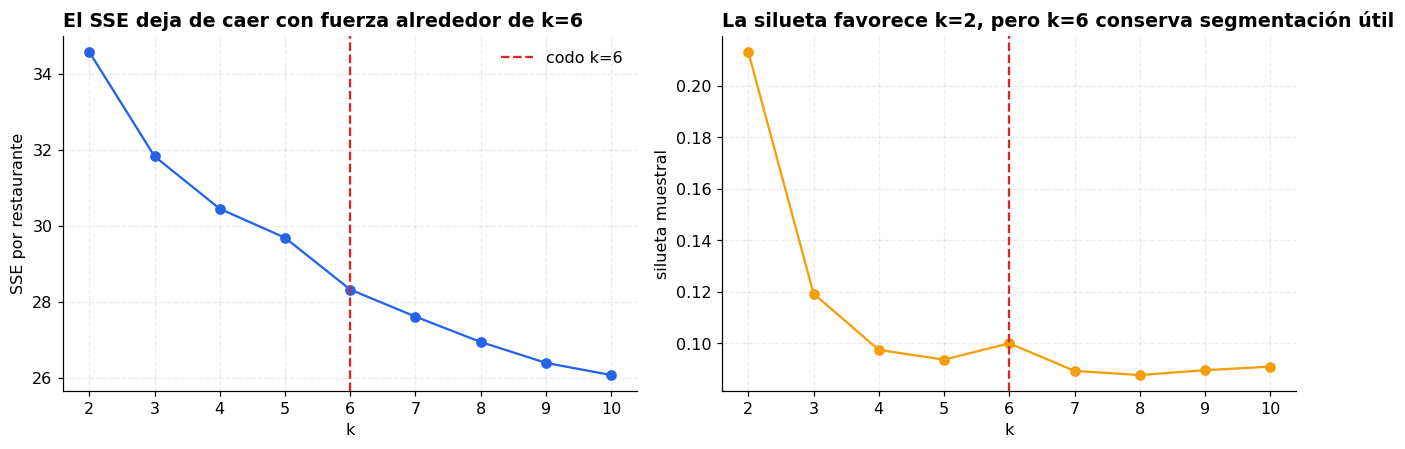

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(barrido["k"], barrido["sse_por_punto"], marker="o", color=viz.PALETA["azul"])
axes[0].axvline(K_CODO, color=viz.PALETA["rojo"], ls="--", label=f"codo k={K_CODO}")
axes[0].set_title("El SSE deja de caer con fuerza alrededor de k=6")
axes[0].set_xlabel("k"); axes[0].set_ylabel("SSE por restaurante"); axes[0].legend()

axes[1].plot(barrido["k"], barrido["silueta"], marker="o", color=viz.PALETA["naranja"])
axes[1].axvline(K_CODO, color=viz.PALETA["rojo"], ls="--")
axes[1].set_title("La silueta favorece k=2, pero k=6 conserva segmentación útil")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silueta muestral")

print(viz.guardar(fig, "parte3_codo_silueta_kmeans"))
plt.show()

La silueta máxima aparece en `k=2`, una división demasiado gruesa para segmentar restaurantes. El codo automático cae en **k=6** y su silueta sigue siendo similar a las soluciones vecinas. Elegimos **k=6** como compromiso entre compacidad e interpretabilidad; no escogemos el número que produce la métrica más alta sin mirar qué significa.

In [6]:
K_FINAL = K_CODO
t0 = time.perf_counter()
km = clustering.kmeans(X, K_FINAL, seed=SEED, init="++")
tiempo_km = time.perf_counter() - t0
sil_km = clustering.silhouette_score(X, km["labels"], sample_size=1200, seed=SEED)
perfil_km = clustering.resumen_clusters(df, km["labels"])

print(f"K-Means++ final: k={K_FINAL}, {km['n_iter']} iteraciones, {tiempo_km:.2f}s")
print(f"SSE={km['sse']:,.0f} | silueta={sil_km:.3f}")
display(perfil_km)

K-Means++ final: k=6, 75 iteraciones, 0.81s
SSE=830,181 | silueta=0.101


,cluster,n,pct,metro_top,stars_media,reviews_mediana,precio_medio,ingreso_mediana,pct_univ_media,delivery_%,outdoor_%,reservas_%,alcohol_top,wifi_top
0,0,3671,12.5,Philadelphia (57%),3.42,57.0,2.07,90890.0,0.51,26.8,54.4,65.6,full_bar (85%),free (48%)
1,1,8325,28.4,Philadelphia (65%),3.50,39.0,1.32,81241.0,0.44,66.2,29.4,12.5,none (91%),no (59%)
2,2,3162,10.8,Philadelphia (57%),3.60,10.0,1.61,78415.0,0.42,37.1,13.9,4.2,missing (92%),missing (90%)
3,3,6060,20.7,Philadelphia (48%),3.81,135.0,1.94,83034.0,0.48,61.3,61.0,57.9,full_bar (50%),free (70%)
4,4,4973,17.0,Philadelphia (60%),3.15,12.0,1.41,72424.0,0.40,51.3,18.8,16.1,missing (44%),missing (67%)
5,5,3123,10.7,Philadelphia (58%),3.83,20.0,1.46,80527.0,0.44,63.9,33.9,12.8,missing (50%),free (52%)


Los seis grupos no son ciudades disfrazadas: todos tienen Philadelphia como mercado más frecuente porque es el 58% del universo, pero ninguno queda monopolizado por una ciudad. La separación principal es operativa:

- servicio completo con bar/reservas;
- casual económico orientado a delivery;
- negocios con poca información y baja actividad;
- destinos consolidados, muy reseñados y bien valorados;
- pequeños locales de menor tracción;
- casuales bien valorados con servicios digitales.

La silueta cercana a 0.10 confirma que son perfiles solapados, no especies perfectamente separadas. En un mercado real eso es esperable.

In [7]:
# Estabilidad: K-Means++ vs inicialización aleatoria en 10 semillas
filas_init = []
for semilla in range(SEED, SEED + 10):
    for init in ("++", "random"):
        r = clustering.kmeans(X, K_FINAL, seed=semilla, init=init)
        filas_init.append({"seed": semilla, "init": init, "sse": r["sse"], "iters": r["n_iter"]})
estabilidad = pd.DataFrame(filas_init)
display(estabilidad.groupby("init").agg(
    SSE_media=("sse", "mean"), SSE_desv=("sse", "std"),
    SSE_mejor=("sse", "min"), iter_media=("iters", "mean")
).round(1))

,SSE_media,SSE_desv,SSE_mejor,iter_media
init,,,,
++,827660.7,4791.1,823544.0,53.2
random,831650.4,7379.4,825464.5,55.7


K-Means++ no gana en todas las semillas, pero en promedio obtiene menor SSE y menor variabilidad que la inicialización aleatoria. Ese es exactamente el aporte del `++`: reducir el riesgo de empezar con centroides amontonados, no garantizar el óptimo global en cada corrida.

docs/figs/parte3_perfiles_clusters.png


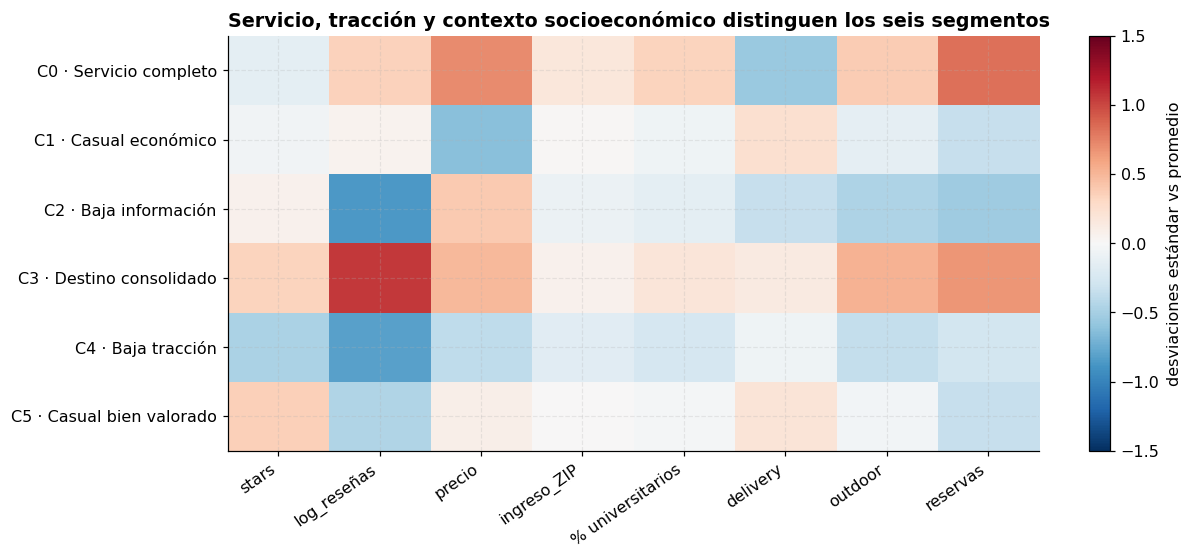

In [8]:
# Perfil visual: medias por cluster en variables interpretables
nombres_cortos = {
    0: "Servicio completo",
    1: "Casual económico",
    2: "Baja información",
    3: "Destino consolidado",
    4: "Baja tracción",
    5: "Casual bien valorado",
}
colores_cluster = [viz.PALETA[c] for c in ("azul", "naranja", "gris", "rojo", "morado", "verde")]

perfil = pd.DataFrame({
    "stars": df["stars"],
    "log_reseñas": np.log1p(df["review_count"]),
    "precio": df["price_range"].fillna(df["price_range"].median()),
    "ingreso_ZIP": df["mediana_ingreso"].fillna(df["mediana_ingreso"].median()),
    "% universitarios": df["pct_universitarios"].fillna(df["pct_universitarios"].median()),
    "delivery": df["RestaurantsDelivery"].astype("boolean").fillna(False).astype(float),
    "outdoor": df["OutdoorSeating"].astype("boolean").fillna(False).astype(float),
    "reservas": df["RestaurantsReservations"].astype("boolean").fillna(False).astype(float),
})
medias_cluster = perfil.assign(cluster=km["labels"]).groupby("cluster").mean()
z = (medias_cluster - perfil.mean()) / perfil.std()

fig, ax = plt.subplots(figsize=(11.5, 5.2))
im = ax.imshow(z, cmap="RdBu_r", vmin=-1.5, vmax=1.5, aspect="auto")
ax.set_xticks(range(z.shape[1]), z.columns, rotation=35, ha="right")
ax.set_yticks(range(K_FINAL), [f"C{i} · {nombres_cortos[i]}" for i in range(K_FINAL)])
ax.set_title("Servicio, tracción y contexto socioeconómico distinguen los seis segmentos")
fig.colorbar(im, ax=ax, label="desviaciones estándar vs promedio")
print(viz.guardar(fig, "parte3_perfiles_clusters"))
plt.show()


### ¿Qué tan sólido es cada cluster?

La silueta promedio puede ocultar grupos muy distintos. Calculamos también la silueta individual sobre una muestra reproducible y la mostramos junto al tamaño real de cada segmento: valores positivos indican una asignación más cercana al propio cluster; valores negativos señalan restaurantes fronterizos.


docs/figs/parte3_diagnostico_clusters.png


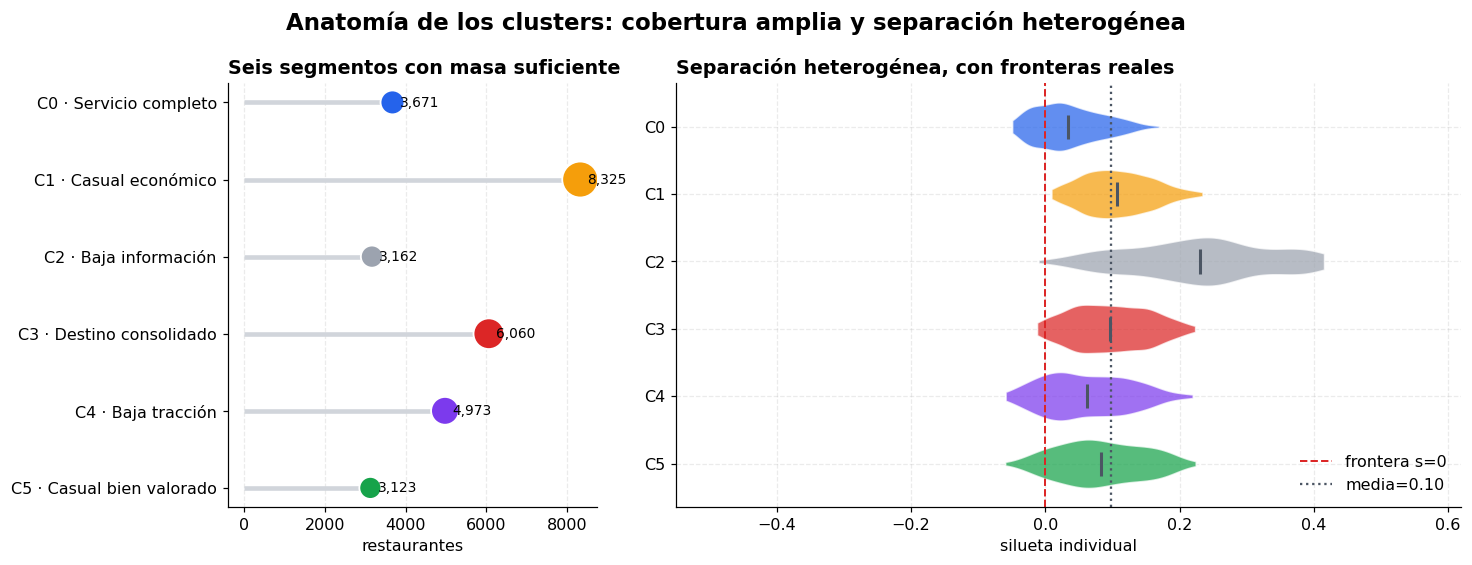

,media,mediana,pct_negativa,n
cluster,,,,
0,0.034,0.028,28.302,3671
1,0.107,0.104,0.000,8325
2,0.230,0.238,0.402,3162
3,0.097,0.093,3.232,6060
4,0.062,0.058,18.490,4973
5,0.083,0.077,10.182,3123


In [9]:
ids_sil, vals_sil = clustering.silhouette_samples(
    X, km["labels"], sample_size=2400, seed=SEED
)
sil_detalle = pd.DataFrame({
    "cluster": km["labels"][ids_sil],
    "silueta": vals_sil,
})
tamanos = pd.Series(km["labels"]).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), gridspec_kw={"width_ratios": [0.8, 1.7]})
y = np.arange(K_FINAL)

# Lollipop: el área de cada punto hace visible el peso del segmento.
axes[0].hlines(y, 0, tamanos.values, color="#d1d5db", lw=3)
axes[0].scatter(tamanos.values, y, s=tamanos.values / 15,
                color=colores_cluster, edgecolor="white", linewidth=1.2, zorder=3)
for yi, n in zip(y, tamanos.values):
    axes[0].text(n + 180, yi, f"{n:,}", va="center", fontsize=9)
axes[0].set_yticks(y, [f"C{i} · {nombres_cortos[i]}" for i in y])
axes[0].invert_yaxis()
axes[0].set_xlabel("restaurantes")
axes[0].set_title("Seis segmentos con masa suficiente")
axes[0].grid(axis="y", visible=False)

series = [sil_detalle.loc[sil_detalle["cluster"] == c, "silueta"].to_numpy()
          for c in range(K_FINAL)]
parts = axes[1].violinplot(series, positions=y, vert=False, widths=0.72,
                           showmeans=True, showmedians=False, showextrema=False)
for body, color in zip(parts["bodies"], colores_cluster):
    body.set_facecolor(color)
    body.set_edgecolor("white")
    body.set_alpha(0.72)
parts["cmeans"].set_color(viz.PALETA["gris_oscuro"])
parts["cmeans"].set_linewidth(2)
axes[1].axvline(0, color=viz.PALETA["rojo"], ls="--", lw=1.3, label="frontera s=0")
axes[1].axvline(vals_sil.mean(), color=viz.PALETA["gris_oscuro"], ls=":", lw=1.5,
                label=f"media={vals_sil.mean():.2f}")
axes[1].set_yticks(y, [f"C{i}" for i in y])
axes[1].invert_yaxis()
axes[1].set_xlim(-0.55, 0.62)
axes[1].set_xlabel("silueta individual")
axes[1].set_title("Separación heterogénea, con fronteras reales")
axes[1].legend(loc="lower right")

fig.suptitle("Anatomía de los clusters: cobertura amplia y separación heterogénea",
             fontsize=15, fontweight="bold")
print(viz.guardar(fig, "parte3_diagnostico_clusters"))
plt.show()

display(
    sil_detalle.groupby("cluster")["silueta"]
    .agg(media="mean", mediana="median", pct_negativa=lambda s: 100 * (s < 0).mean())
    .assign(n=tamanos)
    .round(3)
)


El segmento **C2 (baja información)** es el más nítido (`s≈0.23`) y casi no contiene asignaciones negativas. En cambio, **C0 (servicio completo)** y **C4 (baja tracción)** concentran más casos fronterizos (28% y 18%). La lectura humana es importante: `k=6` produce perfiles útiles, pero algunos restaurantes combinan rasgos de más de un segmento y no deben tratarse como categorías rígidas.


### ¿Los clusters son ciudades disfrazadas?

`metro` no participó en el entrenamiento. Lo usamos ahora como etiqueta externa: el ancho de cada columna representa cuántos restaurantes contiene el cluster y su composición vertical muestra qué proporción procede de cada mercado.


docs/figs/parte3_mosaico_mercados_clusters.png


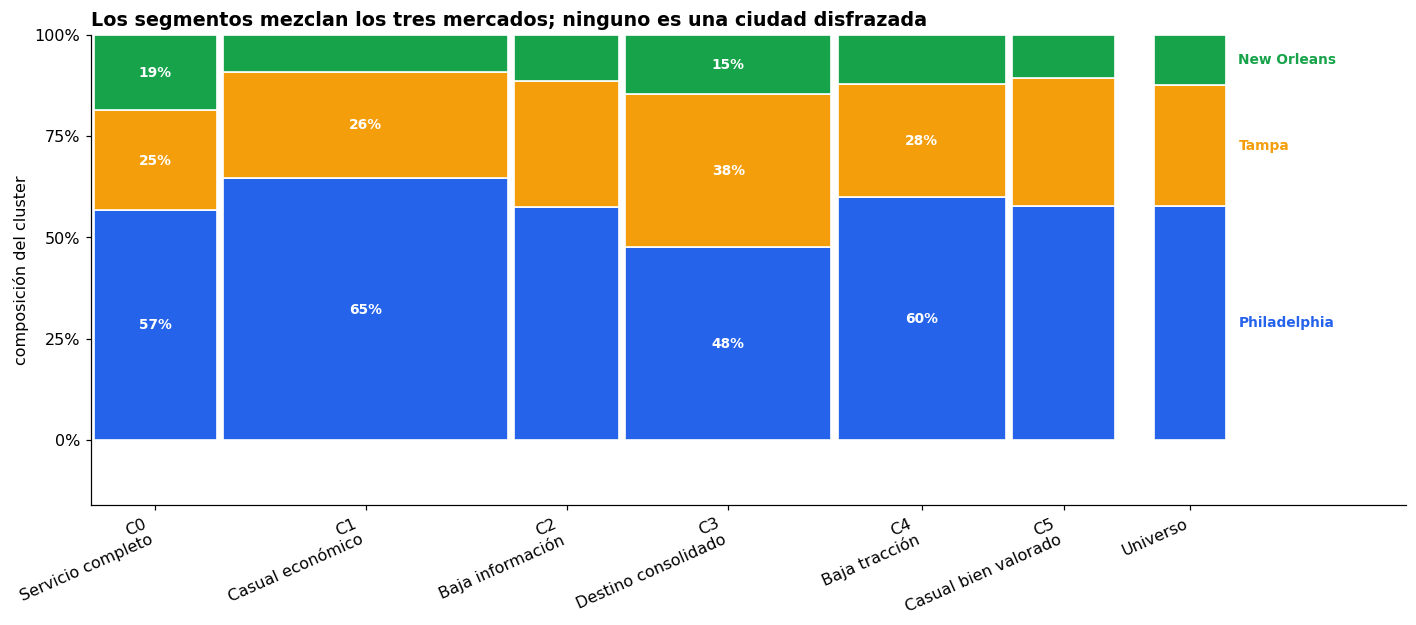

metro,Philadelphia,Tampa,New Orleans
cluster,,,
0,56.7,24.7,18.6
1,64.6,26.3,9.2
2,57.4,31.1,11.4
3,47.6,37.7,14.7
4,59.9,27.8,12.2
5,57.6,31.7,10.7


In [10]:
from matplotlib.patches import Patch, Rectangle

composicion = pd.crosstab(km["labels"], df["metro"]).reindex(
    index=range(K_FINAL), columns=list(viz.MERCADOS), fill_value=0
)
props = composicion.div(composicion.sum(axis=1), axis=0)
anchos = tamanos / tamanos.sum()

fig, ax = plt.subplots(figsize=(13, 5.8))
x0 = 0.0
centros = []
for c in range(K_FINAL):
    ancho = float(anchos.loc[c])
    y0 = 0.0
    for mercado in props.columns:
        alto = float(props.loc[c, mercado])
        ax.add_patch(Rectangle(
            (x0 + 0.003, y0), max(ancho - 0.006, 0), alto,
            facecolor=viz.MERCADOS[mercado], edgecolor="white", linewidth=1.1
        ))
        if alto > 0.13 and ancho > 0.11:
            ax.text(x0 + ancho / 2, y0 + alto / 2, f"{alto:.0%}",
                    ha="center", va="center", color="white", fontweight="bold", fontsize=9)
        y0 += alto
    centros.append(x0 + ancho / 2)
    x0 += ancho

# Barra de referencia: composición del universo completo.
base = df["metro"].value_counts(normalize=True).reindex(props.columns)
x_ref, w_ref, y0 = 1.035, 0.07, 0.0
for mercado in props.columns:
    alto = float(base.loc[mercado])
    ax.add_patch(Rectangle((x_ref, y0), w_ref, alto, facecolor=viz.MERCADOS[mercado],
                           edgecolor="white", linewidth=1.1))
    ax.text(x_ref + w_ref + 0.012, y0 + alto / 2, mercado,
            va="center", color=viz.MERCADOS[mercado], fontweight="bold", fontsize=9)
    y0 += alto

ax.set_xlim(0, 1.28)
ax.set_ylim(-0.16, 1)
ax.set_xticks(centros + [x_ref + w_ref / 2],
              [f"C{i}\n{nombres_cortos[i]}" for i in range(K_FINAL)] + ["Universo"],
              rotation=24, ha="right")
ax.set_yticks([0, .25, .5, .75, 1], ["0%", "25%", "50%", "75%", "100%"])
ax.set_ylabel("composición del cluster")
ax.set_title("Los segmentos mezclan los tres mercados; ninguno es una ciudad disfrazada")
ax.grid(False)
print(viz.guardar(fig, "parte3_mosaico_mercados_clusters"))
plt.show()

display((100 * props).round(1).rename_axis("cluster"))


Todos los segmentos mezclan los tres mercados. La mayor desviación aparece en **C3 (destino consolidado)**, con más Tampa (38%) y menos Philadelphia (48%); aun así, ninguna ciudad monopoliza el grupo. La pureza cercana a 0.58 refleja sobre todo el peso base de Philadelphia y el NMI casi nulo confirma que el clustering no está copiando la geografía.


## Paso 4 — DBSCAN: calibrar `eps` y `minPts`

DBSCAN exacto necesita comparar pares de puntos. Sobre 29,314 restaurantes serían más de 859 millones de pares, por lo que usamos una muestra reproducible de 6,000. Fijamos `minPts=10` y observamos la distancia al décimo vecino.

In [11]:
rng = np.random.default_rng(SEED)
ids_db = rng.choice(len(X), size=6000, replace=False)
X_db = X[ids_db]
MIN_PTS = 10

t0 = time.perf_counter()
kdist = clustering.k_distance_values(X_db, k=MIN_PTS, sample_size=len(X_db), seed=SEED)
tiempo_kdist = time.perf_counter() - t0
percentiles = [70, 75, 80, 82, 85, 90, 95]
tabla_eps = pd.DataFrame({
    "percentil": percentiles,
    "eps": np.percentile(kdist, percentiles),
})
display(tabla_eps.round(3))
print(f"k-distance calculado en {tiempo_kdist:.2f}s")

,percentil,eps
0,70,4.830
1,75,4.978
2,80,5.169
3,82,5.246
4,85,5.388
5,90,5.716
6,95,6.174


k-distance calculado en 0.49s


docs/figs/parte3_kdistance_dbscan.png


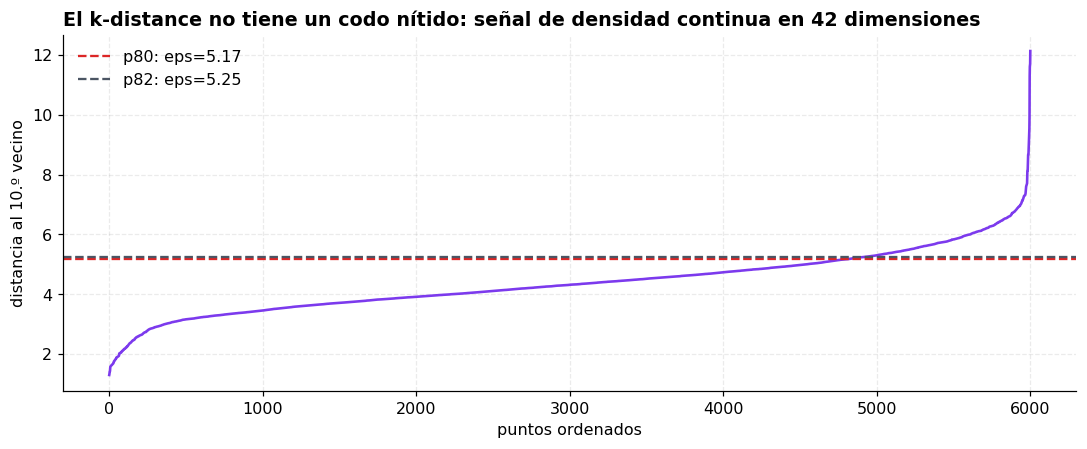

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(np.arange(len(kdist)), kdist, color=viz.PALETA["morado"], lw=1.7)
for q, color in [(80, viz.PALETA["rojo"]), (82, viz.PALETA["gris_oscuro"])]:
    e = float(np.percentile(kdist, q))
    ax.axhline(e, color=color, ls="--", label=f"p{q}: eps={e:.2f}")
ax.set_title("El k-distance no tiene un codo nítido: señal de densidad continua en 42 dimensiones")
ax.set_xlabel("puntos ordenados"); ax.set_ylabel("distancia al 10.º vecino"); ax.legend()
print(viz.guardar(fig, "parte3_kdistance_dbscan"))
plt.show()

In [13]:
# La salida anterior sugiere probar alrededor del p80, antes de que todo se fusione.
pruebas_db = []
resultados_db = {}
for q in (70, 75, 80, 82, 85):
    eps = float(np.percentile(kdist, q))
    t0 = time.perf_counter()
    r = clustering.dbscan(X_db, eps=eps, min_pts=MIN_PTS)
    dt = time.perf_counter() - t0
    sil = clustering.silhouette_score(X_db, r["labels"], sample_size=700, seed=SEED)
    pruebas_db.append({
        "percentil": q, "eps": eps, "clusters": r["n_clusters"],
        "ruido_%": 100 * r["noise"] / len(X_db), "silueta": sil, "segundos": dt,
    })
    resultados_db[q] = r
display(pd.DataFrame(pruebas_db).round(3))

,percentil,eps,clusters,ruido_%,silueta,segundos
0,70,4.830,2,12.417,0.096,0.311
1,75,4.978,2,10.250,0.110,0.314
2,80,5.169,2,7.833,0.113,0.359
3,82,5.246,1,6.950,NaN,0.378
4,85,5.388,1,5.567,NaN,0.428


Entre p80 y p82 ocurre una transición brusca: DBSCAN pasa de dos clusters a uno. Elegimos **p80 (`eps≈5.17`, `minPts=10`)** porque es el último punto antes de la fusión total y conserva detección de ruido. La decisión viene de la salida, no de un valor prefijado.

In [14]:
Q_DB = 80
EPS_DB = float(np.percentile(kdist, Q_DB))
t0 = time.perf_counter()
db = clustering.dbscan(X_db, eps=EPS_DB, min_pts=MIN_PTS, verbose=True)
tiempo_db = time.perf_counter() - t0
sil_db = clustering.silhouette_score(X_db, db["labels"], sample_size=900, seed=SEED)

print("Tamaños:", db["counts"].tolist())
print(f"Ruido: {db['noise']:,}/{len(X_db):,} ({100*db['noise']/len(X_db):.1f}%)")
print(f"Silueta sin ruido: {sil_db:.3f}")

DBSCAN eps=5.169 minPts=10: 2 clusters, ruido=470 (7.8%)
Tamaños: [5519, 11]
Ruido: 470/6,000 (7.8%)
Silueta sin ruido: 0.118


DBSCAN encuentra un cluster gigante, un grupo diminuto y cerca de 8% de ruido. No es una segmentación útil del mercado: en 42 dimensiones las distancias se concentran y una cadena de vecinos termina conectando casi todo. El resultado negativo también es evidencia: DBSCAN detecta anomalías, pero no modela bien estos atributos mixtos sin reducción dimensional previa.

## Paso 5 — BFR: calibrar el umbral de absorción

BFR procesa los 29,314 restaurantes en bloques de 4,000 y conserva en DS únicamente `N`, `SUM` y `SUMSQ`. El umbral se expresa como factor por \(\sqrt{d}\), coherente con una distancia de Mahalanobis acumulada en \(d=42\) dimensiones. Probamos varios factores DS; CS y merge quedan en 1.5.

In [15]:
pruebas_bfr = []
resultados_bfr = {}
for factor in (1.4, 1.5, 1.6, 1.8, 2.0):
    t0 = time.perf_counter()
    r = clustering.bfr(
        X, K_FINAL, seed=SEED, chunk_size=4000, init_size=5000,
        threshold_ds_factor=factor, threshold_cs_factor=1.5,
        threshold_merge_factor=1.5,
    )
    dt = time.perf_counter() - t0
    sil = clustering.silhouette_score(X, r["labels"], sample_size=700, seed=SEED)
    pruebas_bfr.append({
        "factor_DS": factor, "umbral": r["threshold_ds"],
        "outliers_%": 100 * r["outliers"] / len(X),
        "silueta": sil, "segundos": dt,
    })
    resultados_bfr[factor] = r
display(pd.DataFrame(pruebas_bfr).round(3))

,factor_DS,umbral,outliers_%,silueta,segundos
0,1.4,9.073,0.461,0.053,0.830
1,1.5,9.721,0.454,0.062,0.800
2,1.6,10.369,1.566,0.067,0.817
3,1.8,11.665,0.508,0.070,0.793
4,2.0,12.961,0.403,0.066,0.802


La fusión periódica de CS hacia DS mantiene los outliers por debajo de 2% en todo el barrido. Elegimos **factor DS=1.8** porque obtiene la mayor silueta observada y todavía deja cerca de 0.5% de casos sin forzar. La relación no es perfectamente monótona: al cambiar el umbral también cambia cuándo se fusionan los resúmenes intermedios.

In [16]:
FACTOR_BFR = 1.8
t0 = time.perf_counter()
bfr = clustering.bfr(
    X, K_FINAL, seed=SEED, chunk_size=4000, init_size=5000,
    threshold_ds_factor=FACTOR_BFR, threshold_cs_factor=1.5,
    threshold_merge_factor=1.5, verbose=True,
)
tiempo_bfr = time.perf_counter() - t0
sil_bfr = clustering.silhouette_score(X, bfr["labels"], sample_size=1200, seed=SEED)

print("Tamaños DS:", bfr["counts"].tolist())
print(f"Outliers finales: {bfr['outliers']:,} ({100*bfr['outliers']/len(X):.1f}%)")
print(f"Silueta: {sil_bfr:.3f} | tiempo: {tiempo_bfr:.2f}s")
display(clustering.resumen_clusters(df, bfr["labels"]))

  BFR 9,000/29,314: DS=8,973 CS=20 RS=7
  BFR 13,000/29,314: DS=12,926 CS=68 RS=6
  BFR 17,000/29,314: DS=16,933 CS=61 RS=6


  BFR 21,000/29,314: DS=20,904 CS=88 RS=8
  BFR 25,000/29,314: DS=24,881 CS=113 RS=6
  BFR 29,000/29,314: DS=28,854 CS=141 RS=5
  BFR 29,314/29,314: DS=29,165 CS=142 RS=7


Tamaños DS: [5617, 4352, 4821, 3424, 3126, 7825]
Outliers finales: 149 (0.5%)
Silueta: 0.068 | tiempo: 0.82s


,cluster,n,pct,metro_top,stars_media,reviews_mediana,precio_medio,ingreso_mediana,pct_univ_media,delivery_%,outdoor_%,reservas_%,alcohol_top,wifi_top
6,-1,149,0.5,ruido/outlier,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,0,5617,19.2,Philadelphia (58%),3.84,94.0,1.63,91092.0,0.48,66.6,46.8,38.4,none (70%),free (57%)
1,1,4352,14.8,Philadelphia (63%),3.32,29.0,1.22,74094.0,0.40,66.9,22.7,5.4,none (98%),no (63%)
2,2,4821,16.4,Philadelphia (50%),3.53,129.0,2.06,83034.0,0.50,47.3,63.9,64.6,full_bar (100%),free (67%)
3,3,3424,11.7,Philadelphia (57%),3.80,19.0,1.49,81241.0,0.45,60.9,33.8,14.7,missing (49%),free (51%)
4,4,3126,10.7,Philadelphia (58%),3.58,10.0,1.52,76050.0,0.41,40.7,14.1,3.6,missing (92%),missing (91%)
5,5,7825,26.7,Philadelphia (60%),3.32,17.0,1.58,78674.0,0.44,45.7,28.3,26.9,none (41%),missing (48%)


docs/figs/parte3_bfr_progreso.png


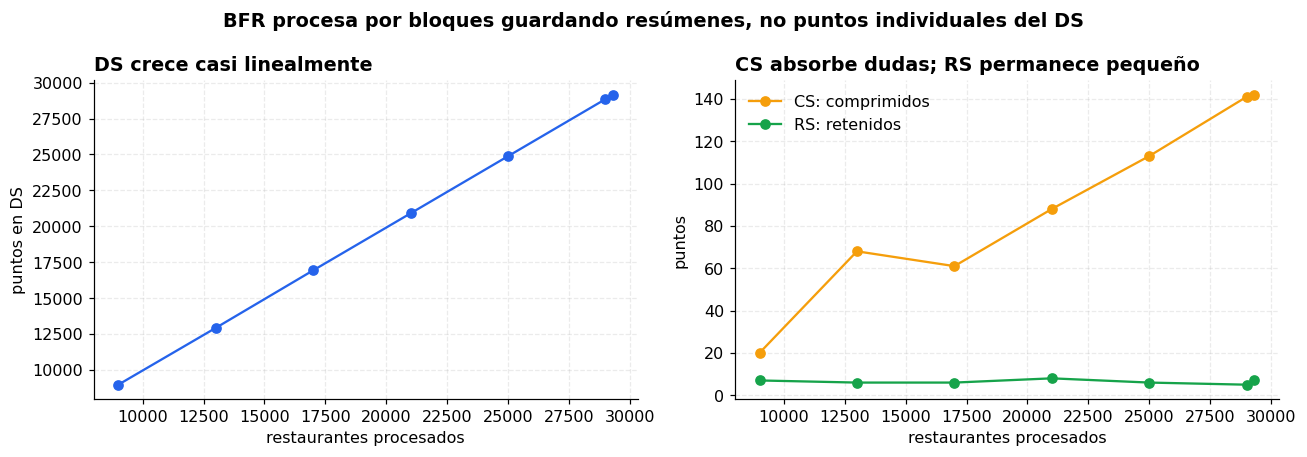

In [17]:
h = bfr["history"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(h["procesados"], h["ds"], marker="o", color=viz.PALETA["azul"])
axes[0].set_title("DS crece casi linealmente")
axes[0].set_xlabel("restaurantes procesados"); axes[0].set_ylabel("puntos en DS")

axes[1].plot(h["procesados"], h["cs_points"], marker="o",
             color=viz.PALETA["naranja"], label="CS: comprimidos")
axes[1].plot(h["procesados"], h["rs"], marker="o",
             color=viz.PALETA["verde"], label="RS: retenidos")
axes[1].set_title("CS absorbe dudas; RS permanece pequeño")
axes[1].set_xlabel("restaurantes procesados"); axes[1].set_ylabel("puntos"); axes[1].legend()

fig.suptitle("BFR procesa por bloques guardando resúmenes, no puntos individuales del DS",
             fontweight="bold")
print(viz.guardar(fig, "parte3_bfr_progreso"))
plt.show()

BFR conserva una segmentación parecida a K-Means++ mientras procesa por bloques y deja explícitos los casos dudosos. Su silueta es algo menor, pero esa pérdida compra escalabilidad: los puntos DS dejan de almacenarse individualmente y quedan representados por estadísticas suficientes.

## Paso 6 — Una misma vista 2D para comparar los tres modelos

Los clusters viven en 42 dimensiones y no pueden dibujarse directamente. Usamos **PCA únicamente como lente visual común**, siguiendo el deck «13. Reducción de Dimensionalidad»: descubrir ejes e interpretar/visualizar (págs. 11–12), ordenar direcciones mediante autovalores y autovectores (págs. 46–47) y reconocer que la proyección es lineal (pág. 67).

PCA se ajusta **una sola vez sobre la matriz estandarizada**, sin mirar las etiquetas. Después proyectamos la misma muestra de 6,000 restaurantes y coloreamos esas coordenadas con K-Means++, DBSCAN y BFR. Las métricas y decisiones permanecen en las 42 dimensiones originales: el mapa permite comparar geometría, pero no reemplaza SSE, silueta ni estabilidad.


PCA validado: componentes ortonormales y PC1 recupera el eje de mayor varianza.
Varianza visible: PC1=23.8% | PC2=8.6% | total 2D=32.4%


docs/figs/parte3_clusters_modelos_pca.png


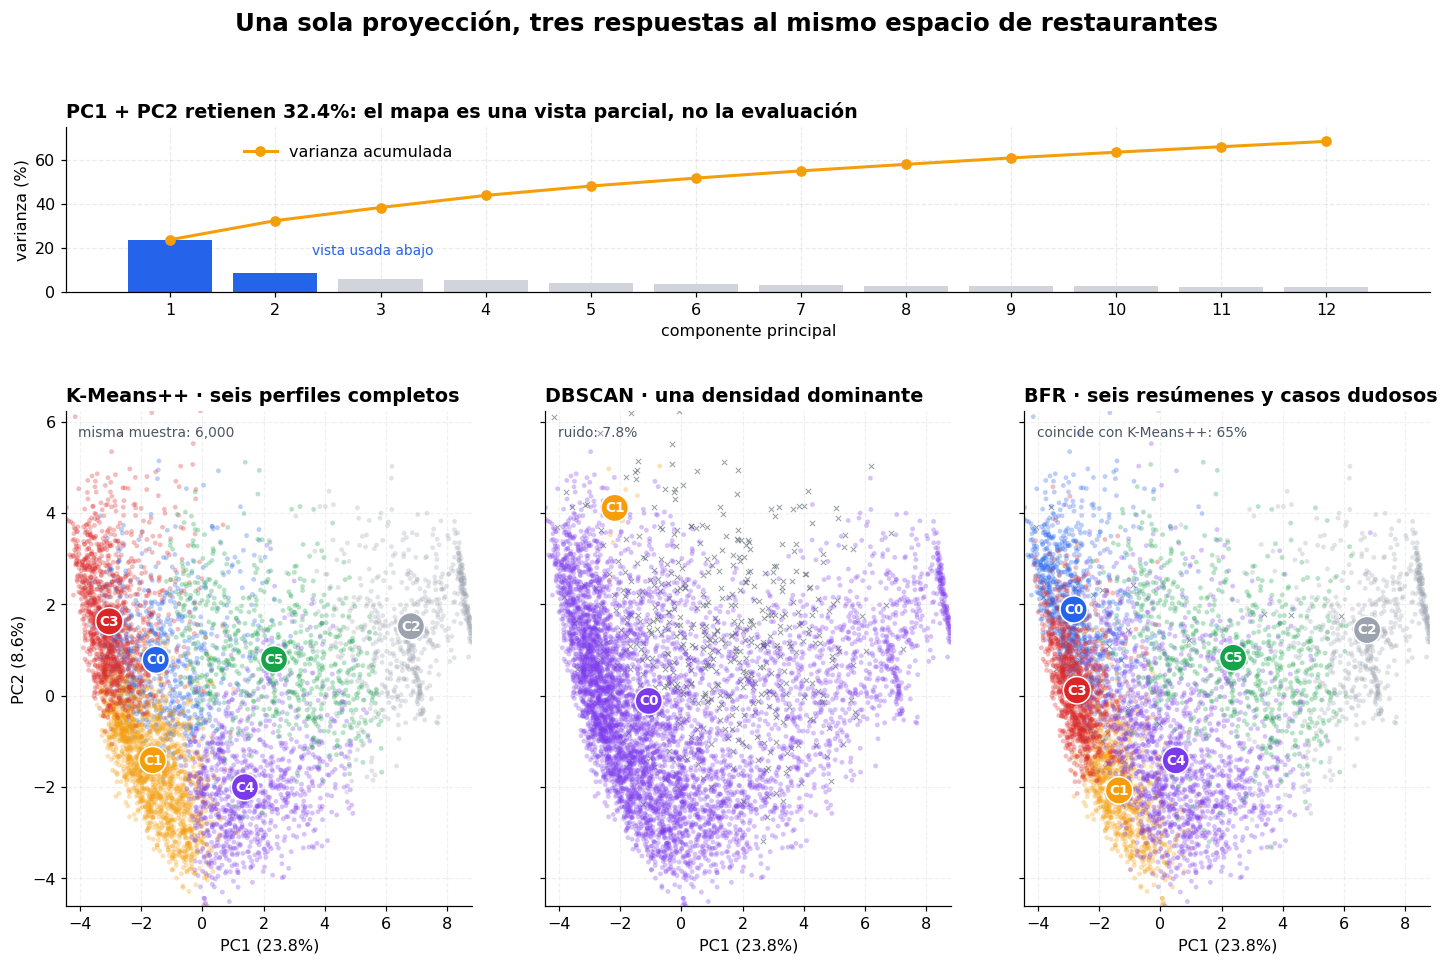

In [18]:
from itertools import permutations

# Validación controlada: si toda la variación está en x, PC1 debe apuntar a x.
toy_pca = np.array([[-3.0, 0.0], [-1.0, 0.0], [1.0, 0.0], [3.0, 0.0]])
check_pca = clustering.pca_proyeccion(toy_pca, n_components=2)
assert np.allclose(check_pca["components"] @ check_pca["components"].T, np.eye(2))
assert np.allclose(np.abs(check_pca["components"][0]), [1.0, 0.0])
print("PCA validado: componentes ortonormales y PC1 recupera el eje de mayor varianza.")

# Ajuste único sobre las 42 features; las etiquetas no intervienen.
pca_viz = clustering.pca_proyeccion(X, n_components=12)
ratio_pca = pca_viz["explained_ratio"]
coords = pca_viz["scores"][ids_db, :2]
var_2d = 100 * ratio_pca[:2].sum()
print(f"Varianza visible: PC1={100*ratio_pca[0]:.1f}% | "
      f"PC2={100*ratio_pca[1]:.1f}% | total 2D={var_2d:.1f}%")

# Los IDs de BFR son arbitrarios. Se alinean con K-Means++ solo para compartir colores.
lab_km = km["labels"][ids_db]
lab_bfr_raw = bfr["labels"][ids_db]
cont = np.zeros((K_FINAL, K_FINAL), dtype=int)
for origen in range(K_FINAL):
    for destino in range(K_FINAL):
        cont[origen, destino] = int(np.sum((lab_bfr_raw == origen) & (lab_km == destino)))
perm = max(permutations(range(K_FINAL)), key=lambda p: sum(cont[j, p[j]] for j in range(K_FINAL)))
lab_bfr = np.full_like(lab_bfr_raw, -1)
for origen, destino in enumerate(perm):
    lab_bfr[lab_bfr_raw == origen] = destino
validos_bfr = lab_bfr >= 0
acuerdo_bfr = 100 * np.mean(lab_bfr[validos_bfr] == lab_km[validos_bfr])

auto_layout_previo = plt.rcParams["figure.autolayout"]
plt.rcParams["figure.autolayout"] = False  # GridSpec controla esta figura compleja.
fig = plt.figure(figsize=(16, 9.2))
gs = fig.add_gridspec(2, 3, height_ratios=[0.75, 2.25], hspace=0.36, wspace=0.18)

# La franja superior hace visible cuánto se pierde al bajar a dos dimensiones.
ax_var = fig.add_subplot(gs[0, :])
n_show = 12
pcs = np.arange(1, n_show + 1)
bars = ax_var.bar(pcs, 100 * ratio_pca[:n_show],
                  color=[viz.PALETA["azul"] if i <= 2 else "#d1d5db" for i in pcs])
ax_var.set_xticks(pcs)
ax_var.set_ylabel("varianza (%)")
ax_var.set_xlabel("componente principal")
ax_var.set_title(f"PC1 + PC2 retienen {var_2d:.1f}%: el mapa es una vista parcial, no la evaluación")
ax_var.plot(pcs, 100 * np.cumsum(ratio_pca[:n_show]), color=viz.PALETA["naranja"],
            marker="o", lw=2, label="varianza acumulada")
ax_var.set_ylim(0, 75)
ax_var.legend(loc="upper left", bbox_to_anchor=(0.12, 0.98))
ax_var.text(2.35, max(100 * ratio_pca[:n_show]) * 0.92, "vista usada abajo",
            color=viz.PALETA["azul"], fontsize=9, va="top")

axes = [fig.add_subplot(gs[1, i]) for i in range(3)]

def dibujar_segmentacion(ax, labels, titulo, colores, ruido=True):
    labels = np.asarray(labels)
    for c in sorted(np.unique(labels)):
        mask = labels == c
        if c < 0:
            ax.scatter(coords[mask, 0], coords[mask, 1], s=12, marker="x",
                       color=viz.PALETA["gris_oscuro"], alpha=0.55,
                       linewidths=0.7, rasterized=True, label=f"ruido ({mask.sum():,})")
            continue
        color = colores[int(c) % len(colores)]
        ax.scatter(coords[mask, 0], coords[mask, 1], s=10, color=color,
                   alpha=0.30, edgecolors="none", rasterized=True)
        centro = np.median(coords[mask], axis=0)
        ax.text(centro[0], centro[1], f"C{c}", ha="center", va="center",
                fontsize=9, fontweight="bold", color="white",
                bbox=dict(boxstyle="circle,pad=0.28", fc=color, ec="white", lw=1.0))
    ax.set_title(titulo)
    ax.set_xlabel(f"PC1 ({100*ratio_pca[0]:.1f}%)")
    ax.grid(alpha=0.18)

dibujar_segmentacion(
    axes[0], lab_km, "K-Means++ · seis perfiles completos", colores_cluster, ruido=False
)
dibujar_segmentacion(
    axes[1], db["labels"], "DBSCAN · una densidad dominante", [viz.PALETA["morado"], viz.PALETA["naranja"]]
)
dibujar_segmentacion(
    axes[2], lab_bfr, "BFR · seis resúmenes y casos dudosos", colores_cluster
)

for ax in axes:
    ax.set_xlim(coords[:, 0].min(), coords[:, 0].max())
    ax.set_ylim(coords[:, 1].min(), coords[:, 1].max())
axes[0].set_ylabel(f"PC2 ({100*ratio_pca[1]:.1f}%)")
axes[1].set_yticklabels([])
axes[2].set_yticklabels([])

axes[0].text(0.03, 0.97, "misma muestra: 6,000", transform=axes[0].transAxes,
             va="top", fontsize=9, color=viz.PALETA["gris_oscuro"])
axes[1].text(0.03, 0.97, f"ruido: {100*np.mean(db['labels'] < 0):.1f}%",
             transform=axes[1].transAxes, va="top", fontsize=9,
             color=viz.PALETA["gris_oscuro"])
axes[2].text(0.03, 0.97, f"coincide con K-Means++: {acuerdo_bfr:.0f}%",
             transform=axes[2].transAxes, va="top", fontsize=9,
             color=viz.PALETA["gris_oscuro"])

fig.suptitle("Una sola proyección, tres respuestas al mismo espacio de restaurantes",
             fontsize=16, fontweight="bold", y=0.995)
print(viz.guardar(fig, "parte3_clusters_modelos_pca"))
plt.show()
plt.rcParams["figure.autolayout"] = auto_layout_previo


PC1 y PC2 retienen **32.4% de la varianza**: suficiente para comparar tendencias grandes, pero no para juzgar toda la separación. K-Means++ reparte la nube en seis perfiles continuos y BFR conserva una estructura relacionada (**65% de coincidencia** tras alinear sus IDs arbitrarios). DBSCAN conecta casi toda la nube y deja el ruido disperso. El 67.6% no visible explica por qué este mapa es evidencia descriptiva y la evaluación correcta sigue usando las 42 dimensiones.


## Paso 7 — Comparación final y persistencia


In [19]:
def metricas_fila(nombre, XX, labels, tiempo, alcance):
    ok = labels >= 0
    ncl = len(np.unique(labels[ok]))
    return {
        "método": nombre,
        "alcance": alcance,
        "clusters": ncl,
        "outliers_%": 100 * (~ok).mean(),
        "SSE/punto": clustering.sse(XX, labels) / max(ok.sum(), 1),
        "silueta": clustering.silhouette_score(XX, labels, sample_size=900, seed=SEED),
        "purity_metro": clustering.purity(labels, df.loc[ids_db, "metro"].to_numpy()
                                          if alcance == "muestra 6k" else df["metro"].to_numpy()),
        "NMI_metro": clustering.nmi(labels, df.loc[ids_db, "metro"].to_numpy()
                                    if alcance == "muestra 6k" else df["metro"].to_numpy()),
        "segundos": tiempo,
    }

comparativa = pd.DataFrame([
    metricas_fila("K-Means++", X, km["labels"], tiempo_km, "universo"),
    metricas_fila("DBSCAN", X_db, db["labels"], tiempo_db, "muestra 6k"),
    metricas_fila("BFR", X, bfr["labels"], tiempo_bfr, "universo"),
])
display(comparativa.round(3))

,método,alcance,clusters,outliers_%,SSE/punto,silueta,purity_metro,NMI_metro,segundos
0,K-Means++,universo,6,0.000,28.320,0.100,0.578,0.008,0.809
1,DBSCAN,muestra 6k,2,7.833,39.214,0.118,0.579,0.002,0.363
2,BFR,universo,6,0.508,28.179,0.068,0.578,0.007,0.824


docs/figs/parte3_comparativa_metodos.png


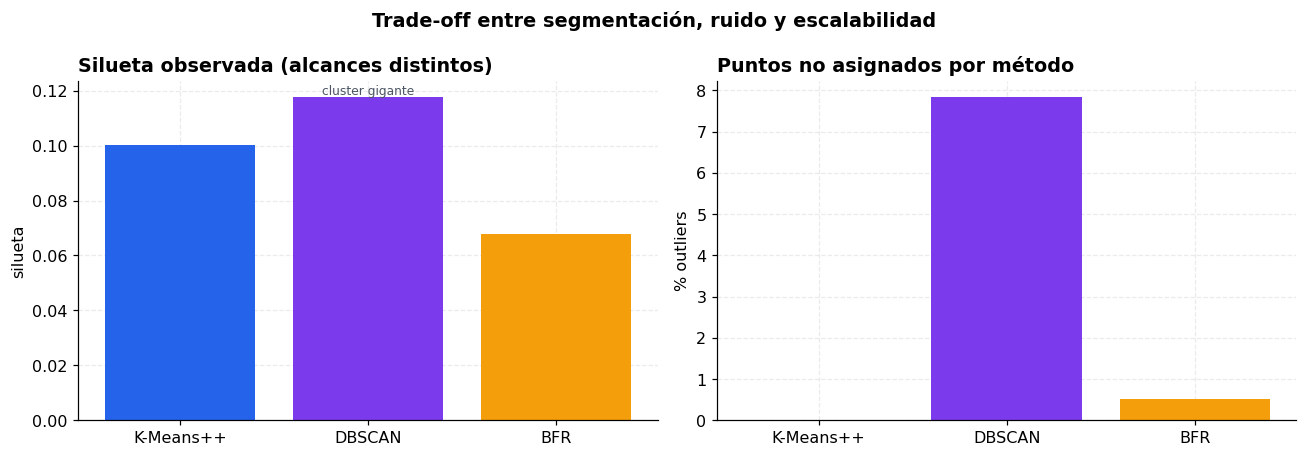

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
colores = [viz.PALETA["azul"], viz.PALETA["morado"], viz.PALETA["naranja"]]

bars = axes[0].bar(comparativa["método"], comparativa["silueta"], color=colores)
axes[0].set_title("Silueta observada (alcances distintos)")
axes[0].set_ylabel("silueta")
axes[0].text(bars[1].get_x() + bars[1].get_width()/2, bars[1].get_height(),
             "cluster gigante", ha="center", va="bottom", fontsize=8,
             color=viz.PALETA["gris_oscuro"])

axes[1].bar(comparativa["método"], comparativa["outliers_%"], color=colores)
axes[1].set_title("Puntos no asignados por método")
axes[1].set_ylabel("% outliers")

fig.suptitle("Trade-off entre segmentación, ruido y escalabilidad", fontweight="bold")
print(viz.guardar(fig, "parte3_comparativa_metodos"))
plt.show()

**Conclusión comparativa.** K-Means++ entrega la segmentación principal por su equilibrio entre cobertura, estabilidad e interpretación. BFR sacrifica algo de separación pero demuestra cómo escalar el mismo problema por bloques. DBSCAN es valioso para detectar ruido, aunque en este espacio alto-dimensional colapsa en una componente de densidad gigante. Purity y NMI respecto a `metro` son muy bajas: la segmentación responde a servicio, tracción y contexto, no a copiar la ciudad.

In [21]:
# Etiquetas interpretables de K-Means++ (derivadas del perfil mostrado arriba)
nombres_cluster = {
    0: "servicio_completo_bar_reservas",
    1: "casual_economico_delivery",
    2: "baja_informacion_baja_actividad",
    3: "destinos_consolidados",
    4: "pequenos_baja_traccion",
    5: "casual_bien_valorado",
}

labels_db_full = np.full(len(df), -2, dtype=np.int32)  # -2 = fuera de la muestra DBSCAN
labels_db_full[ids_db] = db["labels"]

salida = pd.DataFrame({
    "business_id": df["business_id"],
    "cluster_kmeans": km["labels"],
    "segmento_kmeans": pd.Series(km["labels"]).map(nombres_cluster),
    "cluster_bfr": bfr["labels"],
    "dbscan_en_muestra": False,
    "cluster_dbscan": labels_db_full,
})
salida.loc[ids_db, "dbscan_en_muestra"] = True
salida.to_parquet(GOLD / "clusters_negocio.parquet", index=False)

perfil_km.to_parquet(GOLD / "perfiles_clusters_kmeans.parquet", index=False)
comparativa.to_parquet(GOLD / "comparativa_clustering.parquet", index=False)

print("Guardado:", GOLD / "clusters_negocio.parquet", salida.shape)
print("Guardado:", GOLD / "perfiles_clusters_kmeans.parquet", perfil_km.shape)
print("Guardado:", GOLD / "comparativa_clustering.parquet", comparativa.shape)
print("\nFiguras Parte III:")
for p in sorted((GOLD.parent.parent / "docs" / "figs").glob("parte3_*.png")):
    print(" -", p.name)

Guardado: <REPO>/data/gold/clusters_negocio.parquet (29314, 6)
Guardado: <REPO>/data/gold/perfiles_clusters_kmeans.parquet (6, 14)
Guardado: <REPO>/data/gold/comparativa_clustering.parquet (3, 9)

Figuras Parte III:
 - parte3_bfr_progreso.png
 - parte3_clusters_modelos_pca.png
 - parte3_codo_silueta_kmeans.png
 - parte3_comparativa_metodos.png
 - parte3_diagnostico_clusters.png
 - parte3_kdistance_dbscan.png
 - parte3_mosaico_mercados_clusters.png
 - parte3_perfiles_clusters.png


## Resumen del notebook

1. Construimos una matriz de **29,314 restaurantes × 42 features estandarizadas**, sin geografía explícita.
2. K-Means++ quedó validado y el barrido eligió **k=6** por codo, con silueta usada como contraste y no como juez único.
3. Los segmentos se explican por **nivel de servicio, precio, tracción, rating y contexto socioeconómico**.
4. DBSCAN, calibrado con *k-distance*, detectó outliers pero formó un cluster gigante: evidencia de la maldición de dimensionalidad.
5. BFR procesó el universo en bloques con DS/CS/RS y dejó un pequeño conjunto de outliers, mostrando el trade-off escalabilidad/calidad.
6. PCA manual aporta una vista 2D común de K-Means++, DBSCAN y BFR, indicando explícitamente la varianza retenida y sin sustituir las métricas en 42D.

7. Persistimos etiquetas, perfiles, comparación y ocho figuras para el informe.

**Parte III completa:** K-Means++ ✓ · DBSCAN ✓ · BFR ✓ · codo+silueta ✓ · parámetros calibrados por salidas ✓ · comparación ✓ · clusters caracterizados ✓.